<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [ ]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=ef63c50b-bdda-426b-9a8a-167b08581af0
To: /content/sound_classification_dataset.zip
100% 645M/645M [00:04<00:00, 158MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /content/train.csv
100% 3.09k/3.09k [00:00<00:00, 12.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /content/valid.csv
100% 1.06k/1.06k [00:00<00:00, 4.67MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /content/test.csv
100% 719/719 [00:00<00:00, 4.16MB/s]


Разархивируйте zip файл, где содержатся wav файлы датасета.

In [ ]:
!unzip /content/sound_classification_dataset.zip

In [ ]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
train_df.head()

,filename,category
0,1-100032-A-0.wav,dog
1,1-110389-A-0.wav,dog
2,1-17367-A-10.wav,rain
3,1-187207-A-20.wav,crying_baby
4,1-211527-A-20.wav,crying_baby


Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [ ]:
import torch
import torchaudio
from torch.utils.data import Dataset
import os
from torch_audiomentations import Compose, Gain, AddColoredNoise, PitchShift, Shift, PolarityInversion

class SimpleAudioDataset(Dataset):
    """Dataset for waveform classification with torch_audiomentations."""

    def __init__(
        self,
        df,
        audio_dir,
        sample_rate=16000,
        duration_sec=5.0,
        do_augmentation=False,
    ):
        print(df.columns)
        self.df = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.sample_rate = sample_rate
        self.target_num_samples = int(duration_sec * sample_rate)
        self.do_augmentation = do_augmentation

        classes = sorted(self.df["category"].unique().tolist())
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}

        if self.do_augmentation:
            self.augment = Compose(
                transforms=[
                    PolarityInversion(p=0.3),
                    Gain(min_gain_in_db=-6.0, max_gain_in_db=6.0, p=0.6),
                    AddColoredNoise(min_snr_in_db=15.0, max_snr_in_db=30.0, p=0.5),
                    PitchShift(
                        min_transpose_semitones=-1.0,
                        max_transpose_semitones=1.0,
                        sample_rate=sample_rate,
                        p=0.5,
                    ),
                    Shift(min_shift=-0.1, max_shift=0.1, rollover=True, p=0.5),
                ]
            )
        else:
            self.augment = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["filename"]
        label_name = row["category"]
        label = torch.tensor(self.class_to_idx[label_name], dtype=torch.long)

        path = os.path.join(self.audio_dir, filename)
        signal, sr = torchaudio.load(path)

        signal = self._resample(signal, sr)
        signal = self._stereo_to_mono(signal)
        signal = self._fix_length(signal)

        signal = signal.unsqueeze(0)  # [1, 1, T]
        if self.do_augmentation and self.augment is not None:
            signal = self.augment(signal, sample_rate=self.sample_rate)
        signal = signal.squeeze(0)  # [1, T]

        return signal, label

    def _resample(self, signal, sr):
        if sr != self.sample_rate:
            signal = torchaudio.transforms.Resample(sr, self.sample_rate)(signal)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.size(0) > 1:
            signal = signal.mean(dim=0, keepdim=True)
        return signal

    def _fix_length(self, signal):
        _, length = signal.shape
        target = self.target_num_samples
        if length > target:
            signal = signal[:, :target]
        elif length < target:
            pad = torch.zeros((1, target - length))
            signal = torch.cat([signal, pad], dim=1)
        return signal


In [ ]:
train_data = SimpleAudioDataset(
    train_df,
    audio_dir="content/sound_classification_dataset",
    sample_rate=16000,
    duration_sec=5.0,
    do_augmentation=True
)

valid_data = SimpleAudioDataset(
    valid_df,
    audio_dir="content/sound_classification_dataset",
    sample_rate=16000,
    duration_sec=5.0,
    do_augmentation=False
)

Index(['filename', 'category'], dtype='object')
Index(['filename', 'category'], dtype='object')


In [ ]:
train_data[6]

(tensor([[-0.0034, -0.0056, -0.0023,  ...,  0.0036,  0.0008,  0.0048]]),
 tensor(1))

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SoundClassificationModel(nn.Module):
    """A simple CNN model that processes raw waveforms directly."""

    def __init__(self, input_size=16000, num_classes=5):
        super().__init__()

        # Convolutional feature extractor
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(16, 32, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # fcc
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """
        x: Tensor [batch_size, 1, num_samples]
        """
        x = self.conv_block(x)
        x = self.classifier(x)
        return x


### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [ ]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


In [ ]:
train_df

,filename,category
0,1-100032-A-0.wav,dog
1,1-110389-A-0.wav,dog
2,1-17367-A-10.wav,rain
3,1-187207-A-20.wav,crying_baby
4,1-211527-A-20.wav,crying_baby
...,...,...
115,3-170383-A-38.wav,clock_tick
116,3-171012-A-38.wav,clock_tick
117,3-171041-A-38.wav,clock_tick
118,3-180256-A-0.wav,dog


Index(['filename', 'category'], dtype='object')
Index(['filename', 'category'], dtype='object')
Epoch 01/20 | train_loss=1.5881 acc=30.00% | valid_loss=1.6083 acc=20.00% | best_valid_acc=20.00%


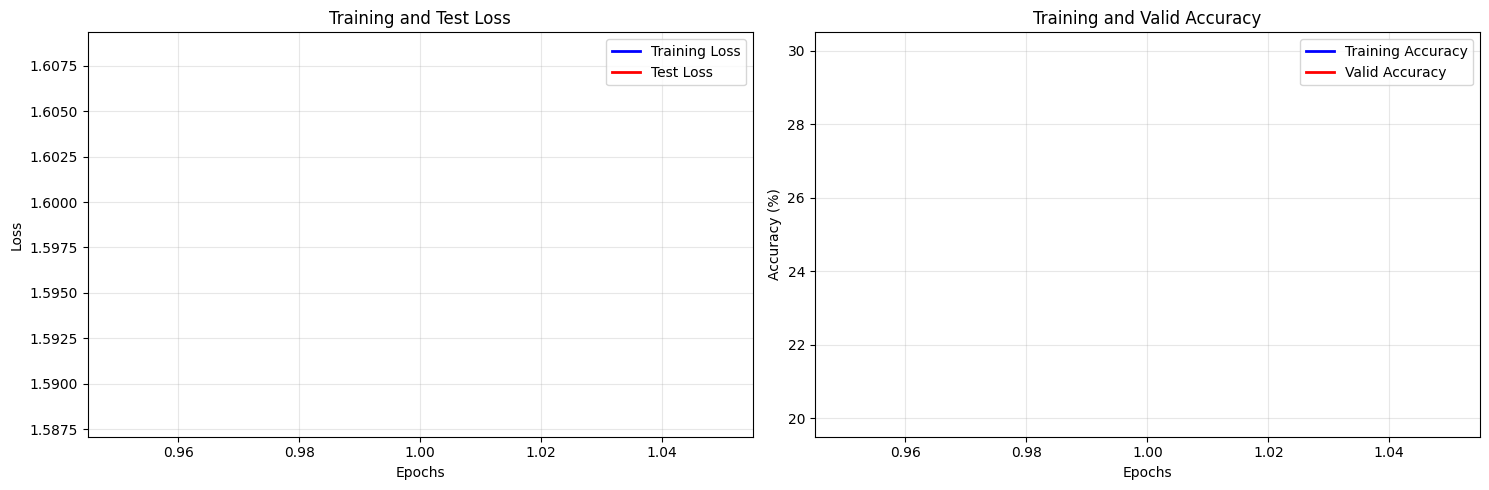

Epoch 02/20 | train_loss=1.4913 acc=50.00% | valid_loss=1.6094 acc=20.00% | best_valid_acc=20.00%


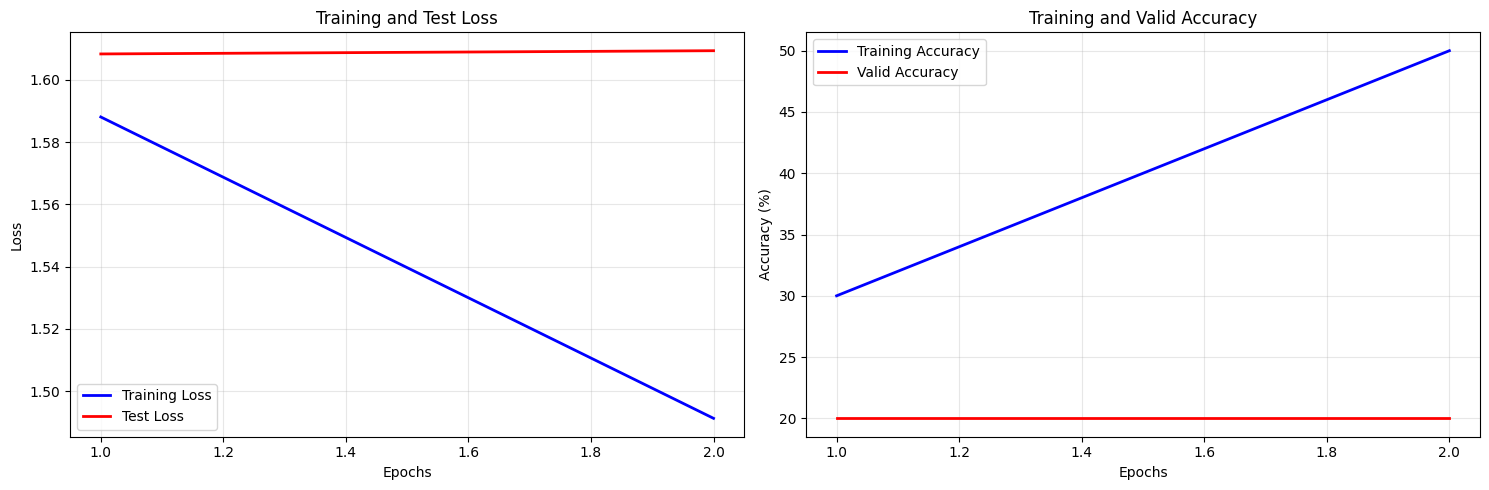

Epoch 03/20 | train_loss=1.4106 acc=59.17% | valid_loss=1.6222 acc=20.00% | best_valid_acc=20.00%


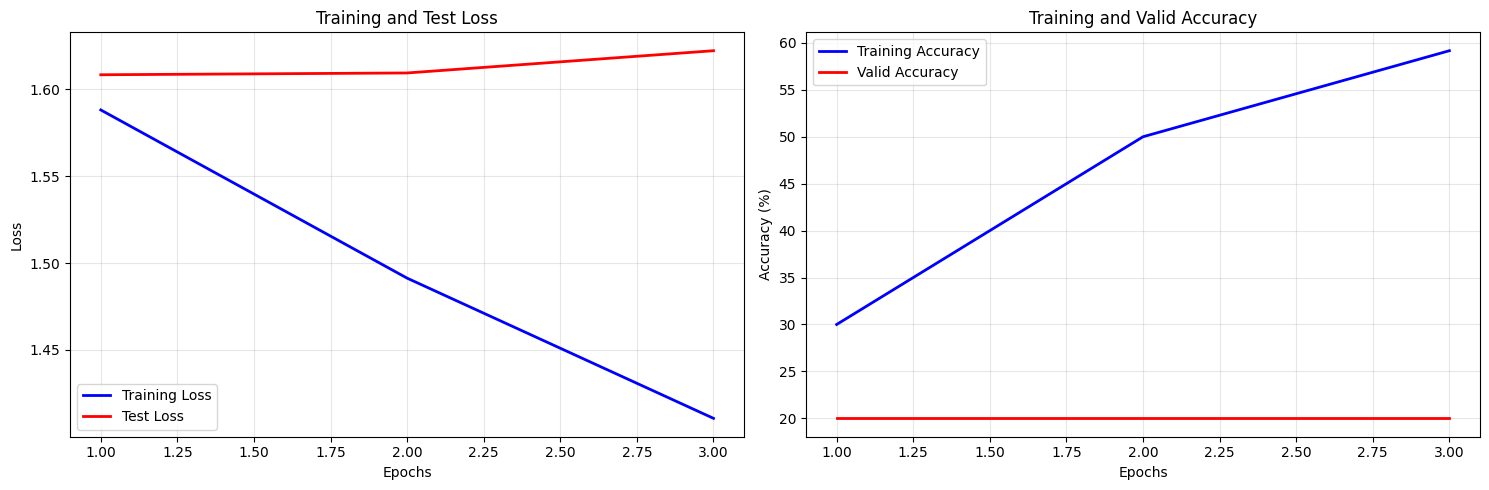

Epoch 04/20 | train_loss=1.2553 acc=62.50% | valid_loss=1.6583 acc=20.00% | best_valid_acc=20.00%


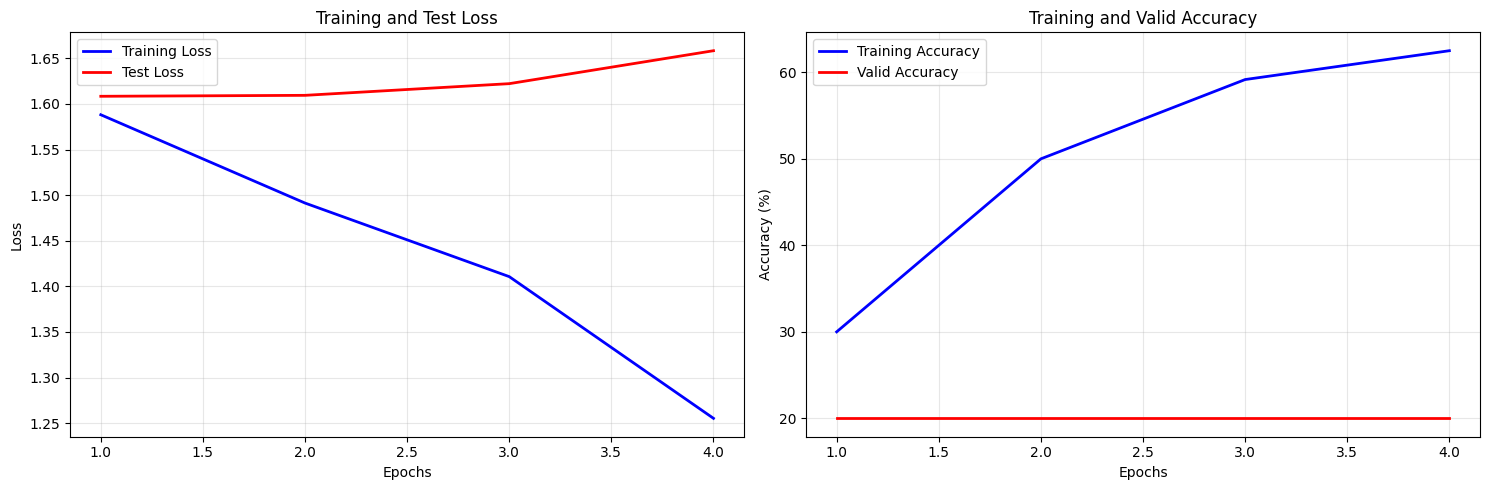

Epoch 05/20 | train_loss=1.2056 acc=57.50% | valid_loss=1.7275 acc=20.00% | best_valid_acc=20.00%


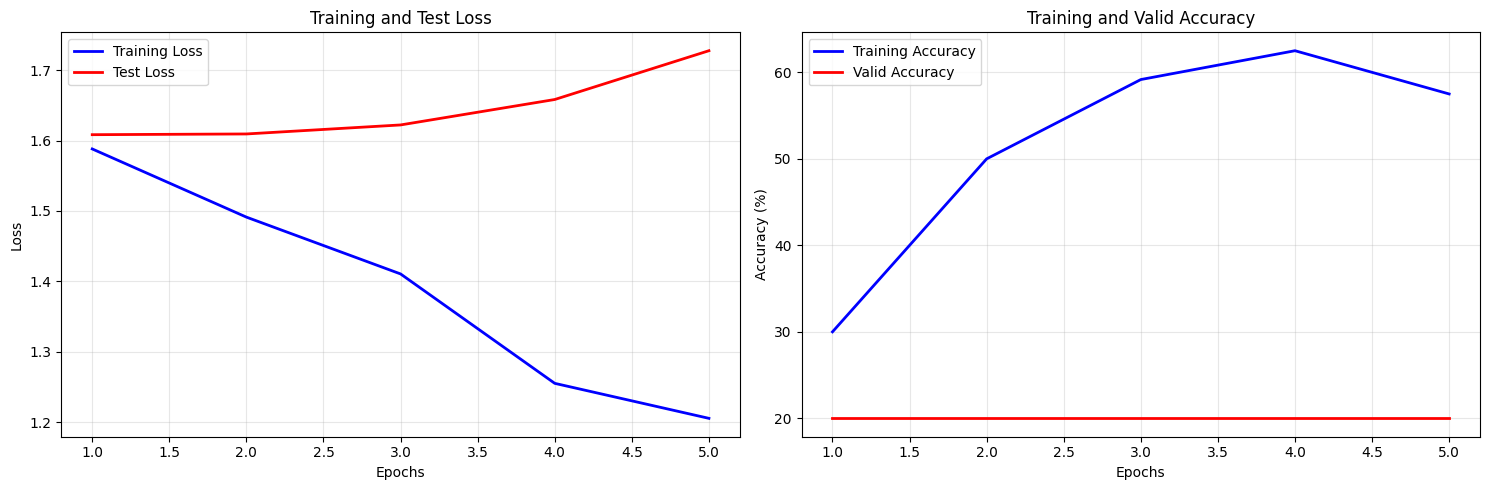

Epoch 06/20 | train_loss=1.1251 acc=65.83% | valid_loss=1.7629 acc=20.00% | best_valid_acc=20.00%


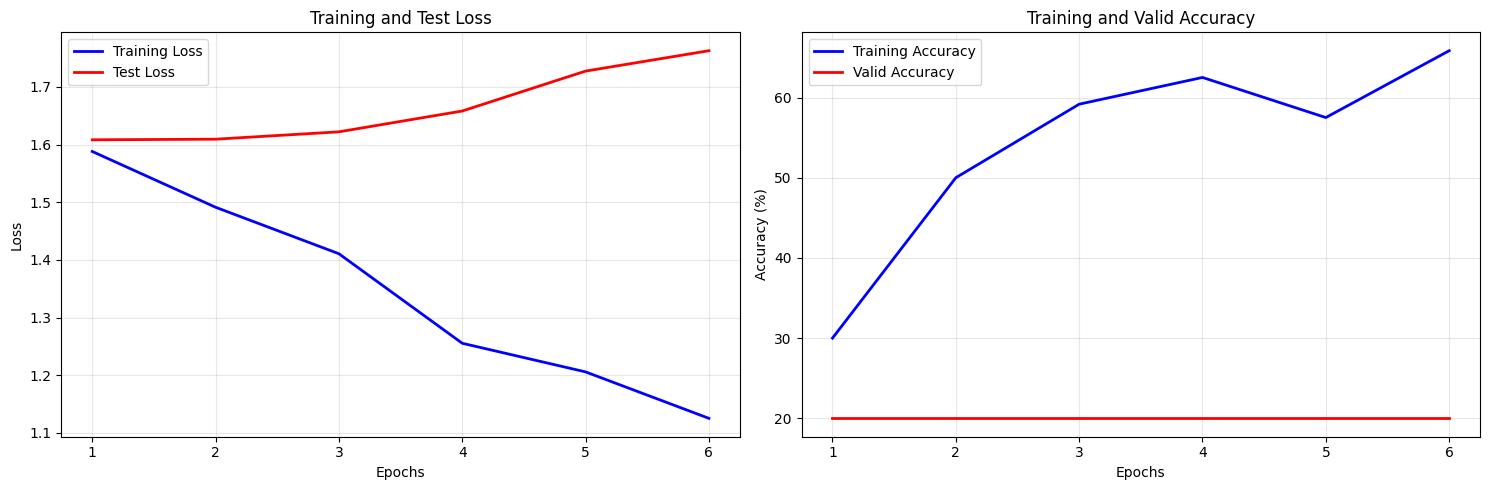

Epoch 07/20 | train_loss=1.0610 acc=59.17% | valid_loss=1.6388 acc=22.50% | best_valid_acc=22.50%


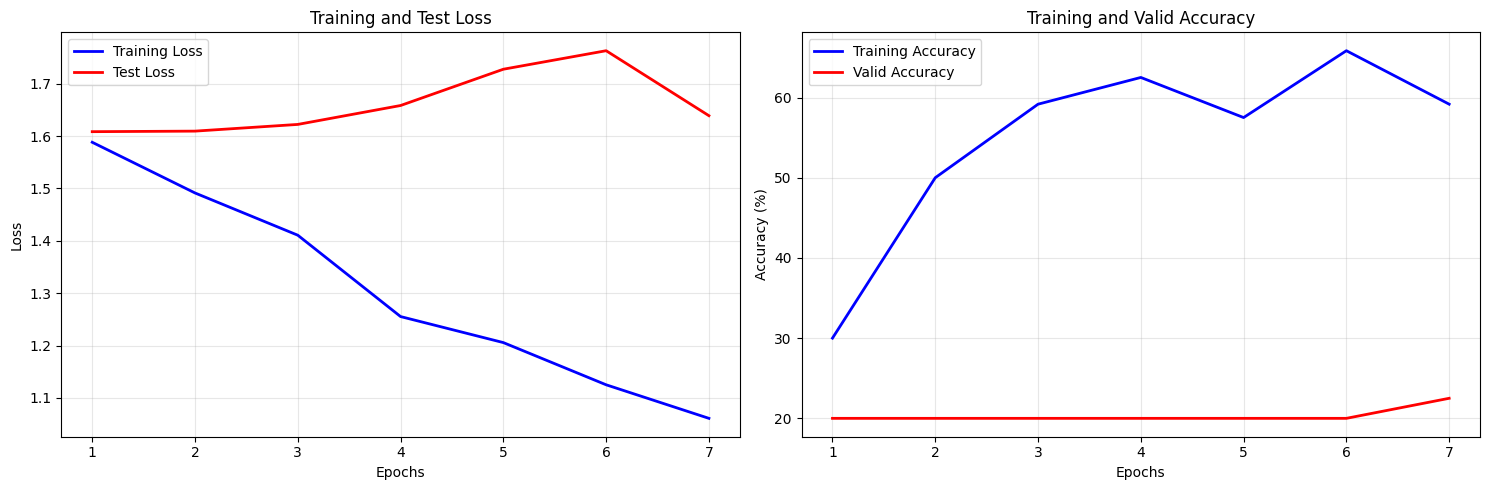

Epoch 08/20 | train_loss=0.9802 acc=64.17% | valid_loss=1.5167 acc=25.00% | best_valid_acc=25.00%


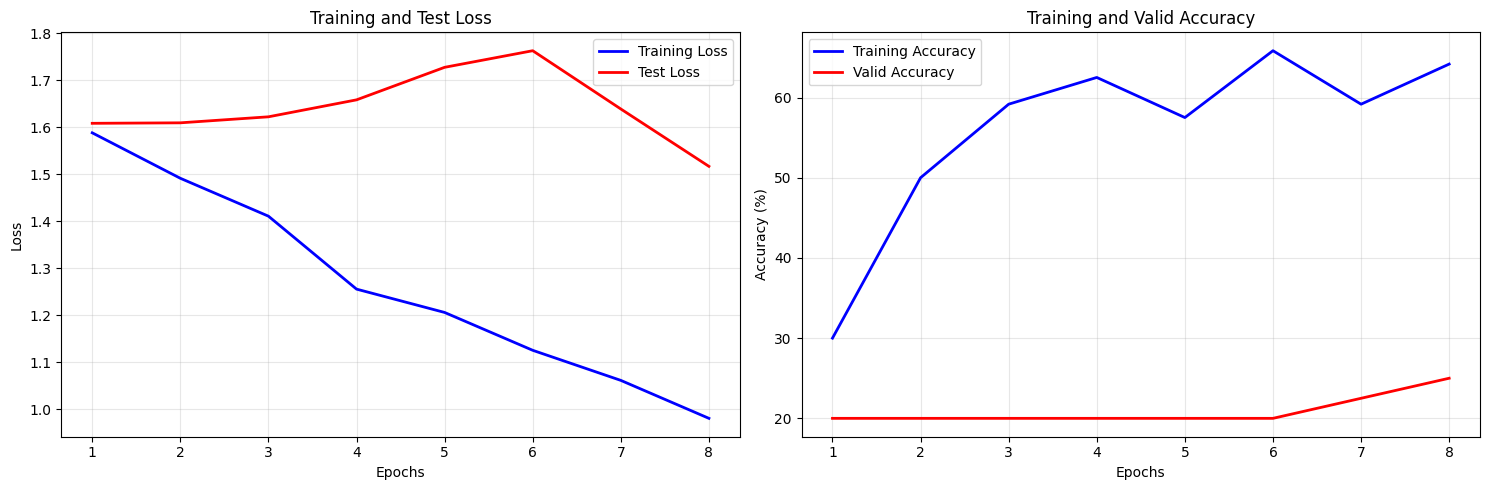

Epoch 09/20 | train_loss=0.9800 acc=57.50% | valid_loss=1.4210 acc=25.00% | best_valid_acc=25.00%


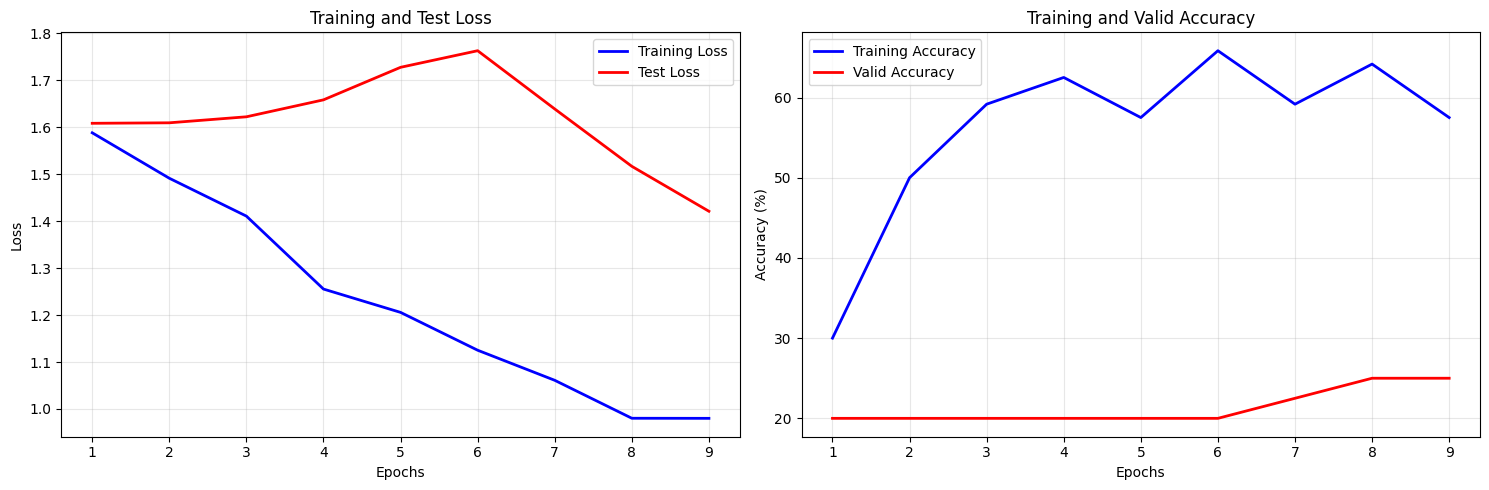

Epoch 10/20 | train_loss=0.8893 acc=67.50% | valid_loss=1.0531 acc=50.00% | best_valid_acc=50.00%


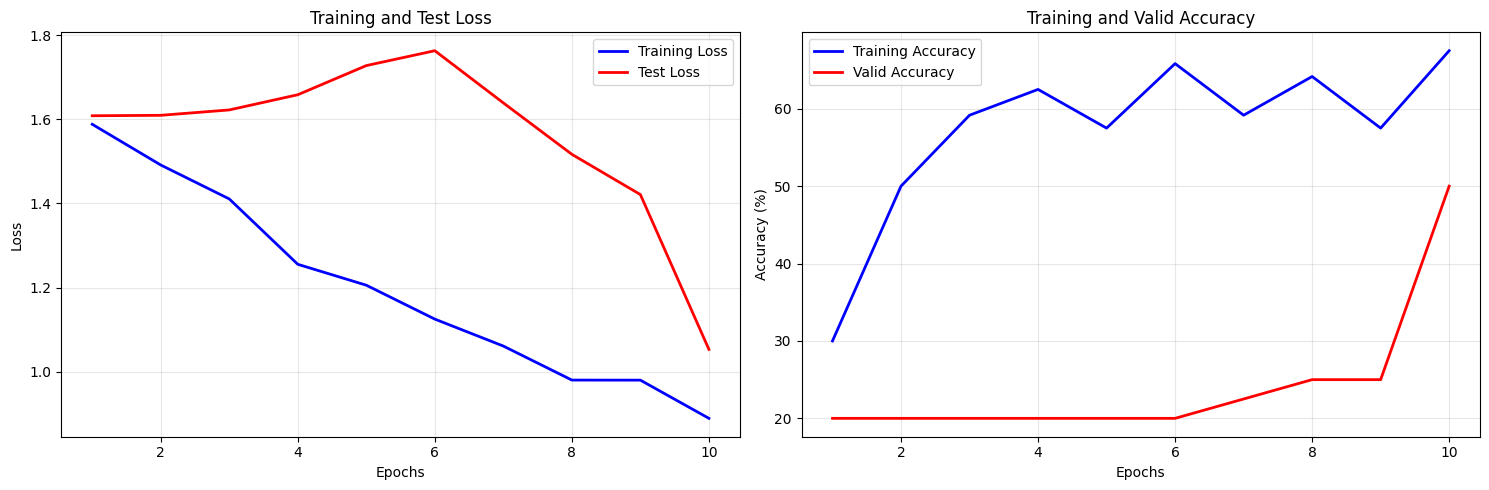

Epoch 11/20 | train_loss=0.8740 acc=75.00% | valid_loss=0.9625 acc=57.50% | best_valid_acc=57.50%


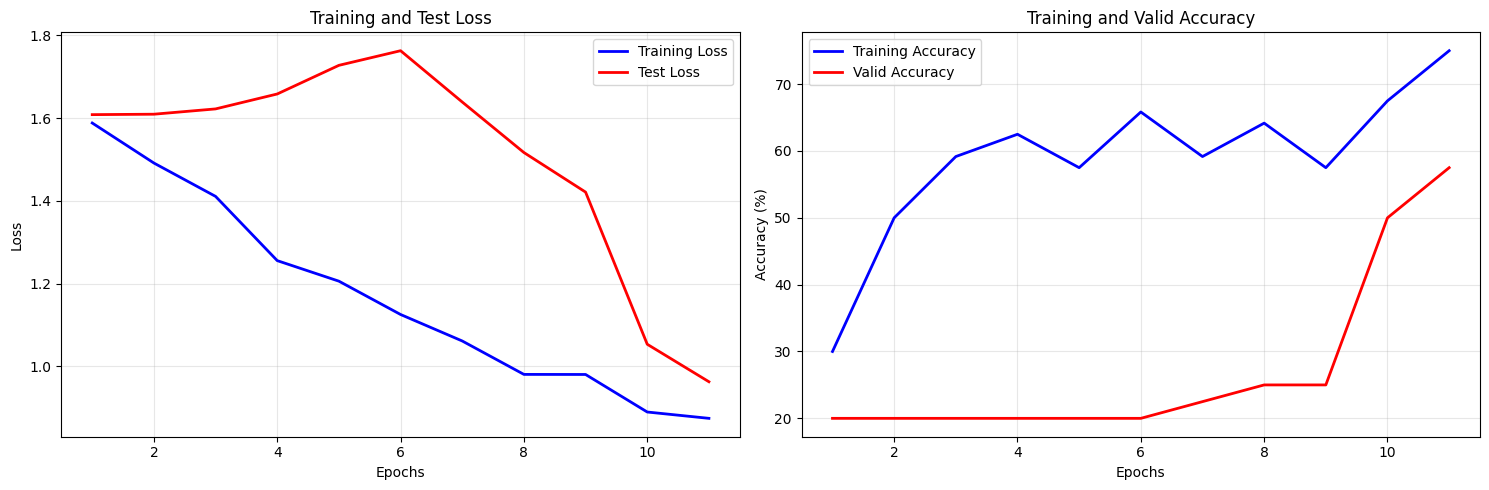

Epoch 12/20 | train_loss=0.7633 acc=71.67% | valid_loss=0.9330 acc=65.00% | best_valid_acc=65.00%


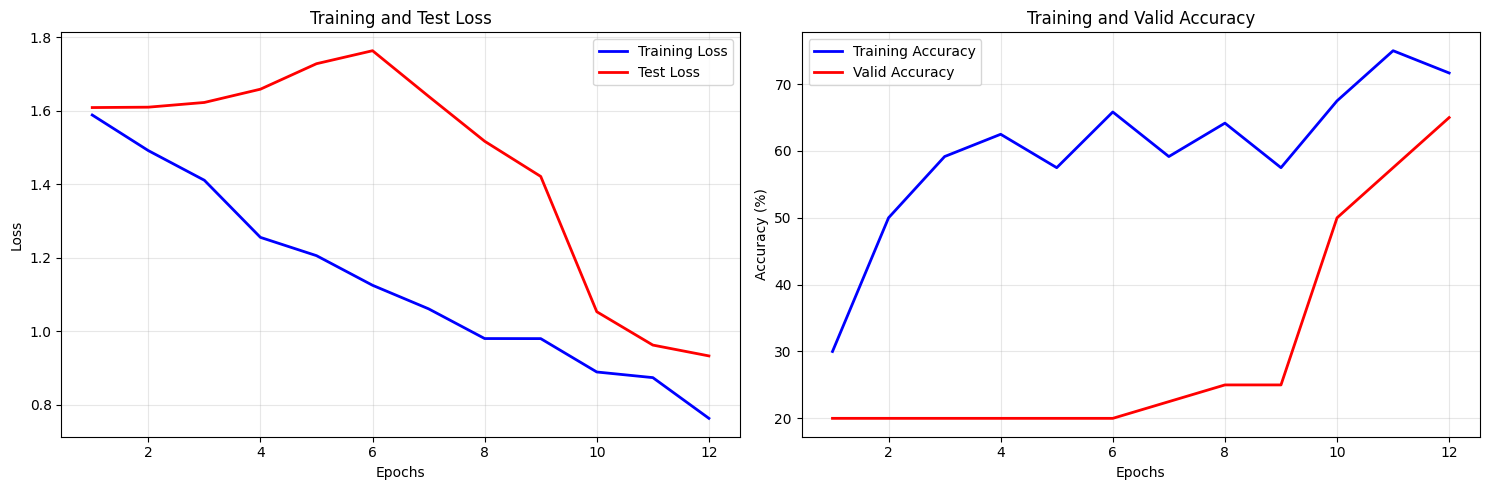

Epoch 13/20 | train_loss=0.7686 acc=65.83% | valid_loss=0.8133 acc=70.00% | best_valid_acc=70.00%


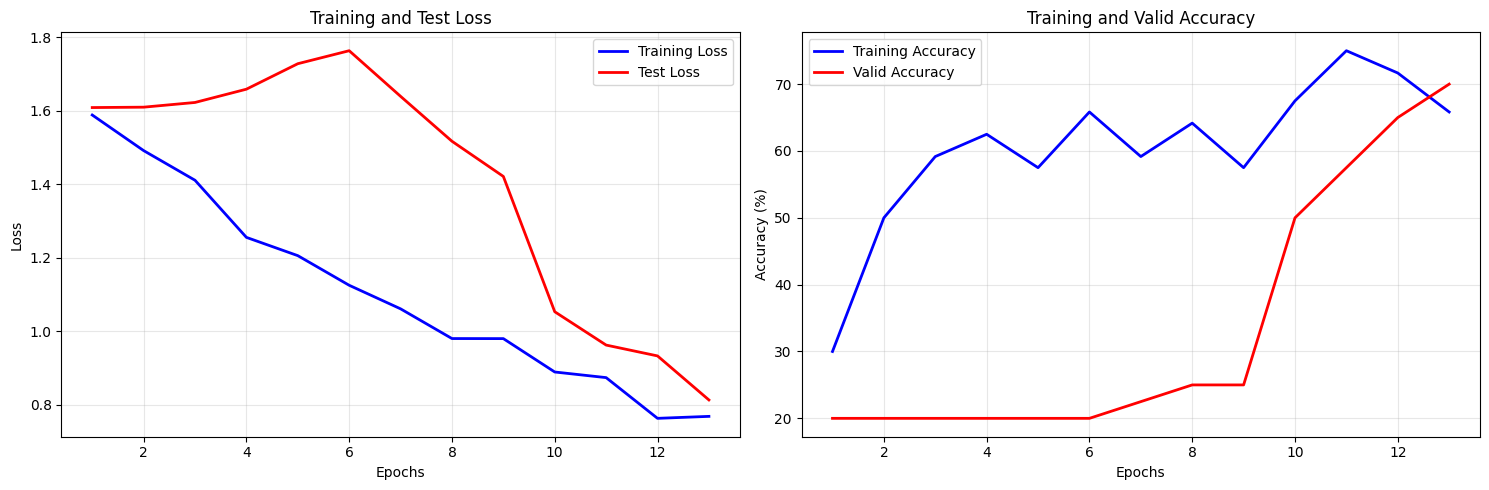

Epoch 14/20 | train_loss=0.7397 acc=73.33% | valid_loss=0.8030 acc=70.00% | best_valid_acc=70.00%


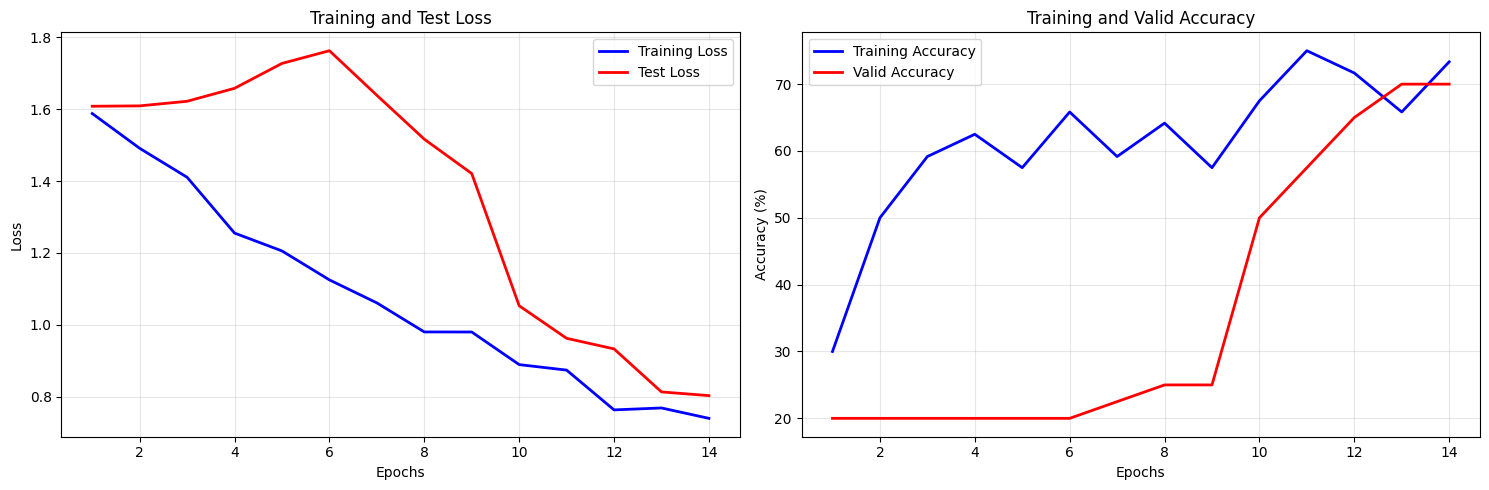

Epoch 15/20 | train_loss=0.6678 acc=77.50% | valid_loss=0.7241 acc=77.50% | best_valid_acc=77.50%


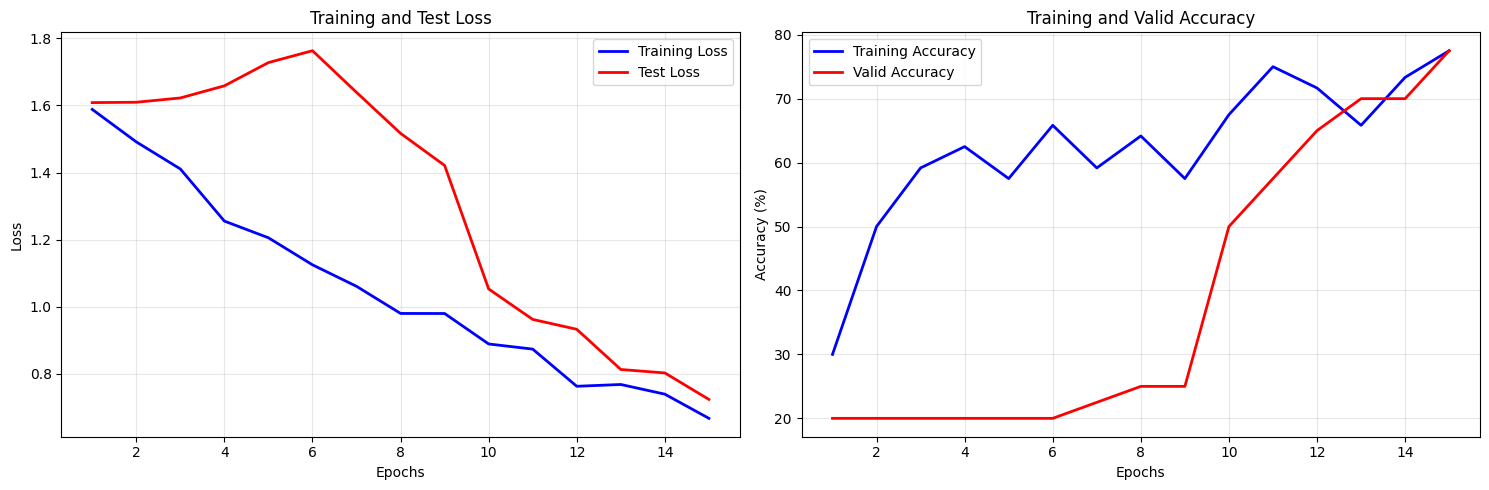

Epoch 16/20 | train_loss=0.6154 acc=86.67% | valid_loss=0.8061 acc=72.50% | best_valid_acc=77.50%


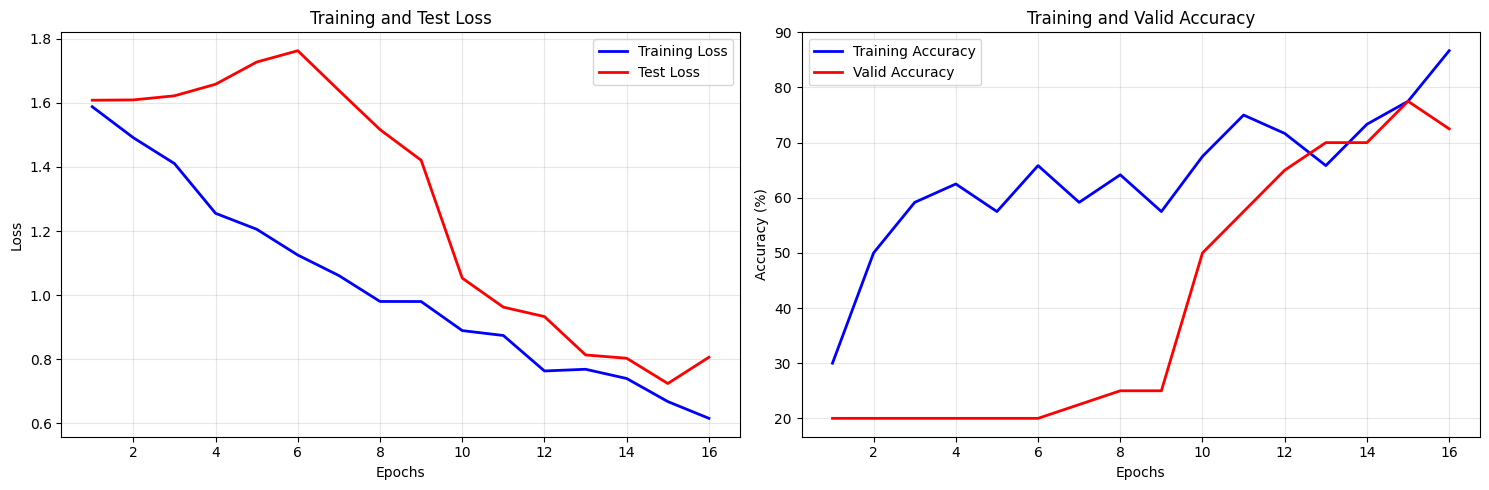

Epoch 17/20 | train_loss=0.6355 acc=76.67% | valid_loss=0.7838 acc=72.50% | best_valid_acc=77.50%


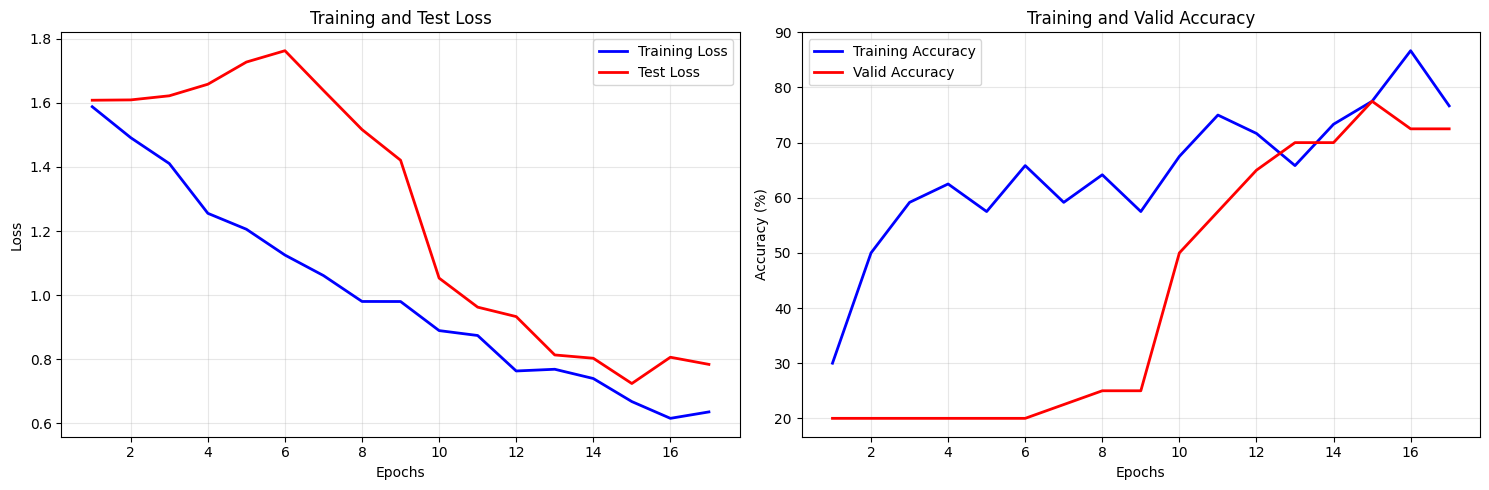

Epoch 18/20 | train_loss=0.6023 acc=79.17% | valid_loss=0.7233 acc=70.00% | best_valid_acc=77.50%


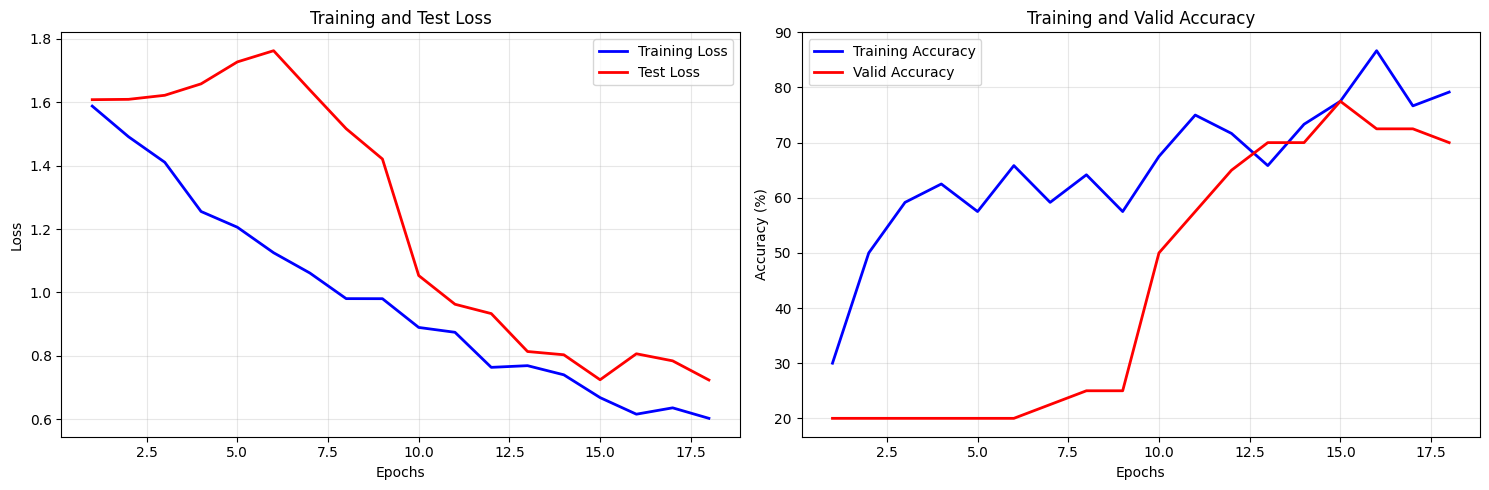

Epoch 19/20 | train_loss=0.6915 acc=75.00% | valid_loss=0.6223 acc=82.50% | best_valid_acc=82.50%


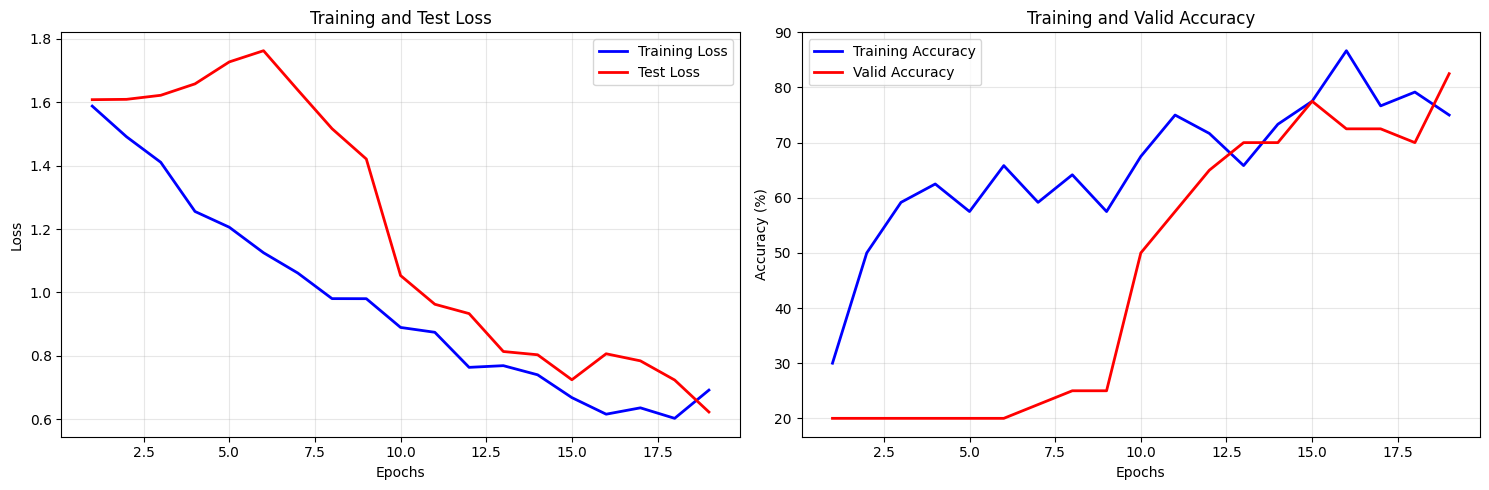

Epoch 20/20 | train_loss=0.6474 acc=80.00% | valid_loss=0.5408 acc=87.50% | best_valid_acc=87.50%


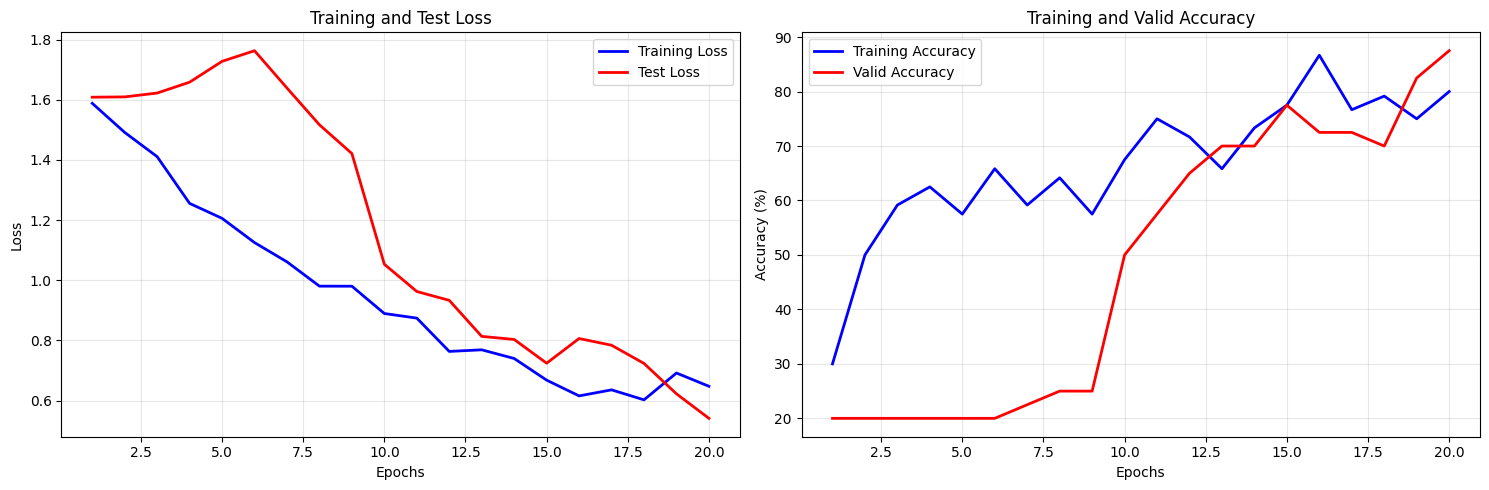


Best train accuracy: 86.67%
Best valid accuracy: 87.50%


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


train_data = SimpleAudioDataset(
    train_df,
    audio_dir="content/sound_classification_dataset",
    sample_rate=16000,
    duration_sec=5.0,
    do_augmentation=True,
)
valid_data = SimpleAudioDataset(
    valid_df,
    audio_dir="content/sound_classification_dataset",
    sample_rate=16000,
    duration_sec=5.0,
    do_augmentation=False,
)
# test_data = SimpleAudioDataset(
#     test_df,
#     audio_dir="content/sound_classification_dataset",
#     sample_rate=16000,
#     duration_sec=5.0,
#     do_augmentation=False,
# )

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
# test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificationModel(num_classes=len(train_data.class_to_idx)).to(device)  # имя класса как в тетрадке
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, train_accuracies = [], []
valid_losses, valid_accuracies = [], []

best_train_acc = 0.0
best_valid_acc = 0.0
best_state = None

n_epochs = 20
for epoch in range(1, n_epochs + 1):

    # ---- Train ----
    model.train()
    running_train_loss = 0.0
    running_train_correct = 0
    running_train_total = 0

    for signals, labels in train_loader:
        # load data to device
        signals, labels = signals.to(device), labels.to(device)  # signals: [B, 1, T]

        # Forward
        logits = model(signals)
        loss = criterion(logits, labels)

        # Accuracy
        preds = torch.argmax(logits, dim=1)
        correct = (preds == labels).sum().item()
        running_train_correct += correct
        running_train_total += labels.size(0)
        running_train_loss += loss.item() * labels.size(0)

        # Backward
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()


    model.eval()
    running_valid_loss = 0.0
    running_valid_correct = 0
    running_valid_total = 0
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)

            logits = model(signals)
            loss = criterion(logits, labels)

            preds = torch.argmax(logits, dim=1)
            running_valid_correct += (preds == labels).sum().item()
            running_valid_total += labels.size(0)
            running_valid_loss += loss.item() * labels.size(0)

    # ---- Epoch metrics ----
    epoch_train_loss = running_train_loss / running_train_total
    epoch_train_acc = 100.0 * running_train_correct / running_train_total

    epoch_valid_loss = running_valid_loss / running_valid_total
    epoch_valid_acc = 100.0 * running_valid_correct / running_valid_total

    # Store & track best
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    if epoch_train_acc > best_train_acc:
        best_train_acc = epoch_train_acc
    if epoch_valid_acc > best_valid_acc:
        best_valid_acc = epoch_valid_acc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{n_epochs} | "
        f"train_loss={epoch_train_loss:.4f} acc={epoch_train_acc:.2f}% | "
        f"valid_loss={epoch_valid_loss:.4f} acc={epoch_valid_acc:.2f}% | "
        f"best_valid_acc={best_valid_acc:.2f}%"
    )

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    # clear_output(wait=True)

if best_state is not None:
    model.load_state_dict(best_state)

print(f"\nBest train accuracy: {best_train_acc:.2f}%")
print(f"Best valid accuracy: {best_valid_acc:.2f}%")


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

In [ ]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_data, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

Using device: cuda


AttributeError: 'SimpleAudioDataset' object has no attribute 'classes'

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [ ]:
# load best
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

from torch.utils.data import DataLoader
import pandas as pd
import torch





tmp_test_df = test_df.copy()
tmp_test_df["category"] = train_df["category"].mode()[0]
test_data = SimpleAudioDataset(
    tmp_test_df,
    audio_dir="content/sound_classification_dataset",
    sample_rate=16000,
    duration_sec=5.0,
    do_augmentation=False,
)

test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


y_test_idx = []
with torch.no_grad():
    for signals, _ in test_loader:      # no category for test
        signals = signals.to(device)
        logits = model(signals)
        preds = torch.argmax(logits, dim=1)
        y_test_idx.append(preds.cpu())

y_test_idx = torch.cat(y_test_idx).numpy()

# idx <-> names of classes
idx_to_class = train_data.idx_to_class
y_test_pred = [idx_to_class[int(i)] for i in y_test_idx]


submission = test_df.copy()
submission["category"] = y_test_pred
submission.to_csv("/content/submission.csv", index=False)

print("✅ Saved /content/submission.csv")
submission.head()


Index(['filename', 'category'], dtype='object')
✅ Saved /content/submission.csv


,filename,category
0,5-151085-A-20.wav,crying_baby
1,5-181766-A-10.wav,crying_baby
2,5-187979-A-21.wav,clock_tick
3,5-188655-A-10.wav,rain
4,5-193339-A-10.wav,rain


### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.

### Аугментация

 Для аугментации, использовал библиотеку torch_audiomentations.

На этапе обучения применялись аугментации:
- Gain (изменение громкости, p=0.6)
- AddColoredNoise (добавление лёгкого фонового шума, p=0.5)
- PitchShift (небольшое смещение тона, ±1 полутон, p=0.5)
- Shift (случайный сдвиг сигнала по времени, p=0.5)
- PolarityInversion (инверсия фазы, p=0.3)


### Модель

Использовал простую 1D-CNN архитектуру


### Training

после анализа кривых обучения на 10 эпохах, я уменьшил интенсивность аугментаций c 0.7 до 0.5, т.к. в первых экспериментах валидационная точность долго оставалась на уровне случайных угадываний около ~20 % аж до 9 эпохи.

Также, увеличил число эпох с 10 до 20, и тогда accuracy на valid стала расти стабильно с каждой эпохой.

